`Project`: Leaf Classification with PyTorch


`Name: Dixin Zhang`




In this assignment, To implement a multi-class leaf classification pipeline in **PyTorch** based on the Kaggle Leaf Classification dataset. The goal is to explore the end-to-end deep learning workflow for image classification, including data preprocessing, exploratory data analysis (EDA), cross-validation design, convolutional neural network (CNN) modeling, and final test prediction.

First examine the dataset structure and class distribution, then prepare the image data for training through resizing, augmentation, and normalization. To ensure a reliable evaluation procedure, using **5-fold stratified cross-validation** so that each fold preserves the class distribution across the 99 leaf species.

Next, building and compare **three CNN models** with different architectures and hyperparameter settings. Their performance is evaluated using `validation loss, accuracy, precision, recall, and macro F1-score`. Then further assess the best-performing model using **multi-class ROC** and **Precision-Recall** analysis.

Finally, after selecting the most effective model, retrainning it and use it to classify the unlabeled test data. The notebook concludes with a discussion of model performance, limitations, and key findings from the experiments.

# SET UP

In [5]:
!"{kaggle_exe}" competitions download -c leaf-classification


  0%|          | 0.00/34.3M [00:00<?, ?B/s]
  3%|2         | 1.00M/34.3M [00:00<00:09, 3.68MB/s]
  6%|5         | 2.00M/34.3M [00:00<00:08, 4.02MB/s]
  9%|8         | 3.00M/34.3M [00:00<00:07, 4.14MB/s]
 12%|#1        | 4.00M/34.3M [00:01<00:07, 4.22MB/s]
 15%|#4        | 5.00M/34.3M [00:01<00:07, 4.28MB/s]
 17%|#7        | 6.00M/34.3M [00:01<00:06, 4.32MB/s]
 20%|##        | 7.00M/34.3M [00:01<00:05, 4.97MB/s]
 26%|##6       | 9.00M/34.3M [00:01<00:03, 7.55MB/s]
 35%|###4      | 12.0M/34.3M [00:01<00:01, 12.2MB/s]
 47%|####6     | 16.0M/34.3M [00:01<00:01, 17.6MB/s]
 58%|#####8    | 20.0M/34.3M [00:02<00:00, 21.2MB/s]
 70%|######9   | 24.0M/34.3M [00:02<00:00, 24.4MB/s]
 79%|#######8  | 27.0M/34.3M [00:02<00:00, 25.3MB/s]
 87%|########7 | 30.0M/34.3M [00:02<00:00, 26.8MB/s]
 96%|#########6| 33.0M/34.3M [00:02<00:00, 27.8MB/s]
100%|##########| 34.3M/34.3M [00:02<00:00, 13.7MB/s]


In [6]:
import zipfile
from pathlib import Path

zip_path = Path("leaf-classification.zip")
extract_path = Path("leaf-classification")

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("extractdone:", extract_path.resolve())

extractdone: C:\Users\zdxzh\Desktop\464\code\leaf-classification


In [7]:
import os
print(os.listdir("leaf-classification"))

['images.zip', 'sample_submission.csv.zip', 'test.csv.zip', 'train.csv.zip']


In [8]:
import zipfile
from pathlib import Path

data_dir = Path("leaf-classification")

for zip_file in data_dir.glob("*.zip"):
    out_dir = data_dir
    with zipfile.ZipFile(zip_file, "r") as z:
        z.extractall(out_dir)
    print(f"done: {zip_file.name}")

done: images.zip
done: sample_submission.csv.zip
done: test.csv.zip
done: train.csv.zip


# 1 Begain

### import

In [1]:
import pandas as pd
from pathlib import Path

data_dir = Path("leaf-classification")

train_df = pd.read_csv(data_dir / "train.csv")
test_df = pd.read_csv(data_dir / "test.csv")
sample_sub_df = pd.read_csv(data_dir / "sample_submission.csv")

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("sample submission shape:", sample_sub_df.shape)

display(train_df.head())
display(test_df.head())
display(sample_sub_df.head())

train shape: (990, 194)
test shape: (594, 193)
sample submission shape: (594, 100)


,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,1,Acer_Opalus,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,...,0.007812,0.000000,0.002930,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391
1,2,Pterocarya_Stenoptera,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,...,0.000977,0.000000,0.000000,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461
2,3,Quercus_Hartwissiana,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,...,0.154300,0.000000,0.005859,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930
3,5,Tilia_Tomentosa,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,...,0.000000,0.000977,0.000000,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852
4,6,Quercus_Variabilis,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,...,0.096680,0.000000,0.021484,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250


,id,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,margin9,...,texture55,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64
0,4,0.019531,0.009766,0.078125,0.011719,0.003906,0.015625,0.005859,0.0,0.005859,...,0.006836,0.000000,0.015625,0.000977,0.015625,0.0,0.0,0.000000,0.003906,0.053711
1,7,0.007812,0.005859,0.064453,0.009766,0.003906,0.013672,0.007812,0.0,0.033203,...,0.000000,0.000000,0.006836,0.001953,0.013672,0.0,0.0,0.000977,0.037109,0.044922
2,9,0.000000,0.000000,0.001953,0.021484,0.041016,0.000000,0.023438,0.0,0.011719,...,0.128910,0.000000,0.000977,0.000000,0.000000,0.0,0.0,0.015625,0.000000,0.000000
3,12,0.000000,0.000000,0.009766,0.011719,0.017578,0.000000,0.003906,0.0,0.003906,...,0.012695,0.015625,0.002930,0.036133,0.013672,0.0,0.0,0.089844,0.000000,0.008789
4,13,0.001953,0.000000,0.015625,0.009766,0.039062,0.000000,0.009766,0.0,0.005859,...,0.000000,0.042969,0.016602,0.010742,0.041016,0.0,0.0,0.007812,0.009766,0.007812


,id,Acer_Capillipes,Acer_Circinatum,Acer_Mono,Acer_Opalus,Acer_Palmatum,Acer_Pictum,Acer_Platanoids,Acer_Rubrum,Acer_Rufinerve,...,Salix_Fragilis,Salix_Intergra,Sorbus_Aria,Tilia_Oliveri,Tilia_Platyphyllos,Tilia_Tomentosa,Ulmus_Bergmanniana,Viburnum_Tinus,Viburnum_x_Rhytidophylloides,Zelkova_Serrata
0,4,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,...,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101
1,7,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,...,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101
2,9,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,...,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101
3,12,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,...,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101
4,13,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,...,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101,0.010101


In [5]:
train_df["image_path"] = train_df["id"].apply(lambda x: str(image_dir / f"{x}.jpg"))
test_df["image_path"] = test_df["id"].apply(lambda x: str(image_dir / f"{x}.jpg"))

display(train_df[["id", "species", "image_path"]].head())
display(test_df[["id", "image_path"]].head())

C:\Users\zdxzh\AppData\Local\Temp\ipykernel_37608\2004562191.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["image_path"] = train_df["id"].apply(lambda x: str(image_dir / f"{x}.jpg"))
C:\Users\zdxzh\AppData\Local\Temp\ipykernel_37608\2004562191.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["image_path"] = test_df["id"].apply(lambda x: str(image_dir / f"{x}.jpg"))


,id,species,image_path
0,1,Acer_Opalus,leaf-classification\images\1.jpg
1,2,Pterocarya_Stenoptera,leaf-classification\images\2.jpg
2,3,Quercus_Hartwissiana,leaf-classification\images\3.jpg
3,5,Tilia_Tomentosa,leaf-classification\images\5.jpg
4,6,Quercus_Variabilis,leaf-classification\images\6.jpg


,id,image_path
0,4,leaf-classification\images\4.jpg
1,7,leaf-classification\images\7.jpg
2,9,leaf-classification\images\9.jpg
3,12,leaf-classification\images\12.jpg
4,13,leaf-classification\images\13.jpg


In [8]:
# Tags encoded into numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df["label"] = le.fit_transform(train_df["species"])

num_classes = train_df["label"].nunique()

print("num_classes:", num_classes)
print("first 10 classes:", le.classes_[:10])
display(train_df[["id", "species", "label"]].head())

num_classes: 99
first 10 classes: ['Acer_Capillipes' 'Acer_Circinatum' 'Acer_Mono' 'Acer_Opalus'
 'Acer_Palmatum' 'Acer_Pictum' 'Acer_Platanoids' 'Acer_Rubrum'
 'Acer_Rufinerve' 'Acer_Saccharinum']


C:\Users\zdxzh\AppData\Local\Temp\ipykernel_37608\3149074862.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["label"] = le.fit_transform(train_df["species"])


,id,species,label
0,1,Acer_Opalus,3
1,2,Pterocarya_Stenoptera,49
2,3,Quercus_Hartwissiana,65
3,5,Tilia_Tomentosa,94
4,6,Quercus_Variabilis,84


# 2 EDA

Number of classes: 99
Samples per class summary:


count    99.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: count, dtype: float64

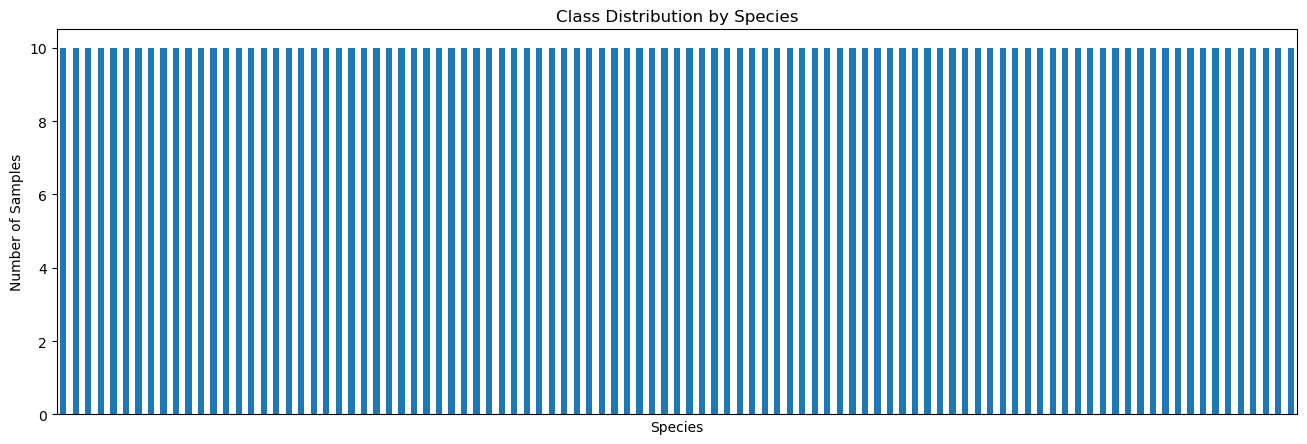

In [23]:
species_counts = train_df["species"].value_counts().sort_values(ascending=False)

print("Number of classes:", train_df["species"].nunique())
print("Samples per class summary:")
display(species_counts.describe())

plt.figure(figsize=(16, 5))
species_counts.plot(kind="bar")
plt.title("Class Distribution by Species")
plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.xticks([], [])
plt.show()

In [24]:
label_mapping_df = pd.DataFrame({
    "species": le.classes_,
    "label": range(len(le.classes_))
})

display(label_mapping_df.head(10))
display(label_mapping_df.tail(10))

,species,label
0,Acer_Capillipes,0
1,Acer_Circinatum,1
2,Acer_Mono,2
3,Acer_Opalus,3
4,Acer_Palmatum,4
5,Acer_Pictum,5
6,Acer_Platanoids,6
7,Acer_Rubrum,7
8,Acer_Rufinerve,8
9,Acer_Saccharinum,9


,species,label
89,Salix_Fragilis,89
90,Salix_Intergra,90
91,Sorbus_Aria,91
92,Tilia_Oliveri,92
93,Tilia_Platyphyllos,93
94,Tilia_Tomentosa,94
95,Ulmus_Bergmanniana,95
96,Viburnum_Tinus,96
97,Viburnum_x_Rhytidophylloides,97
98,Zelkova_Serrata,98


,width,height
count,990.000000,990.000000
mean,691.505051,492.781818
std,259.530001,165.447663
min,165.000000,189.000000
25%,505.000000,373.000000
50%,684.500000,449.000000
75%,876.500000,588.000000
max,1633.000000,1089.000000


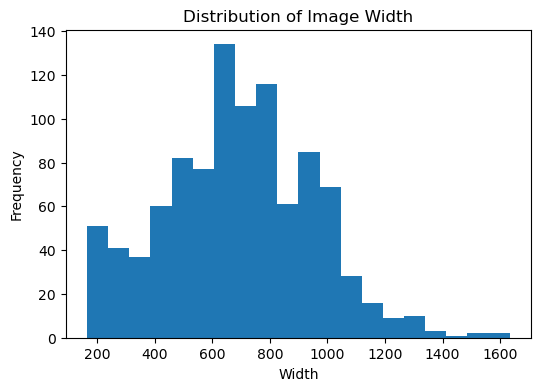

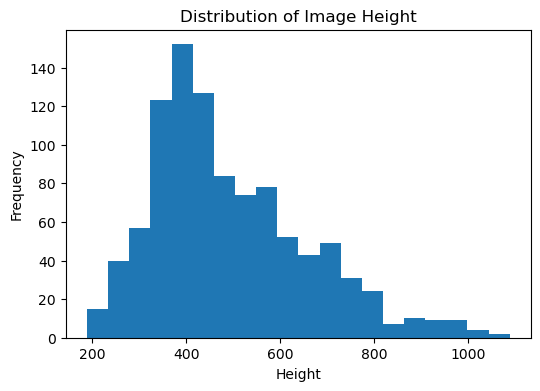

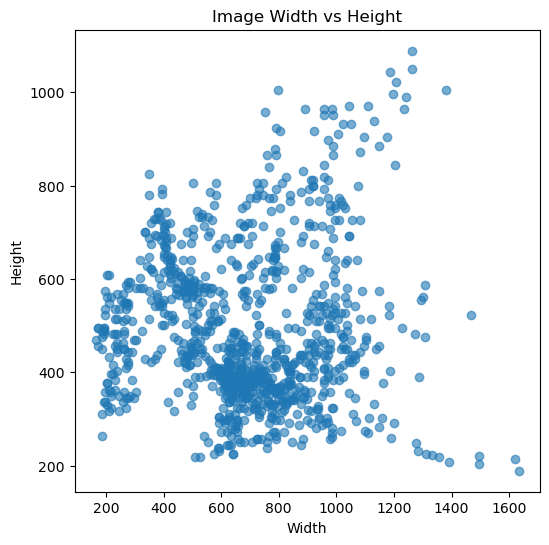

In [25]:
# Inspect image width and height before resizing.

from PIL import Image

image_sizes = []

for path in train_df["image_path"]:
    with Image.open(path) as img:
        w, h = img.size
        image_sizes.append((w, h))

size_df = pd.DataFrame(image_sizes, columns=["width", "height"])
display(size_df.describe())

plt.figure(figsize=(6, 4))
plt.hist(size_df["width"], bins=20)
plt.title("Distribution of Image Width")
plt.xlabel("Width")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(size_df["height"], bins=20)
plt.title("Distribution of Image Height")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(size_df["width"], size_df["height"], alpha=0.6)
plt.title("Image Width vs Height")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

In [27]:
# Check for missing values and invalid image paths.
import os
print("Missing values in train_df:")
display(train_df.isnull().sum())

print("\nMissing values in test_df:")
display(test_df.isnull().sum())

train_df["file_exists"] = train_df["image_path"].apply(os.path.exists)
test_df["file_exists"] = test_df["image_path"].apply(os.path.exists)

print("\nTrain images missing:", (~train_df["file_exists"]).sum())
print("Test images missing:", (~test_df["file_exists"]).sum())

Missing values in train_df:


id            0
species       0
margin1       0
margin2       0
margin3       0
             ..
texture62     0
texture63     0
texture64     0
image_path    0
label         0
Length: 196, dtype: int64


Missing values in test_df:


id            0
margin1       0
margin2       0
margin3       0
margin4       0
             ..
texture61     0
texture62     0
texture63     0
texture64     0
image_path    0
Length: 194, dtype: int64


Train images missing: 0
Test images missing: 0


C:\Users\zdxzh\AppData\Local\Temp\ipykernel_37608\1587999660.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["file_exists"] = train_df["image_path"].apply(os.path.exists)
C:\Users\zdxzh\AppData\Local\Temp\ipykernel_37608\1587999660.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["file_exists"] = test_df["image_path"].apply(os.path.exists)


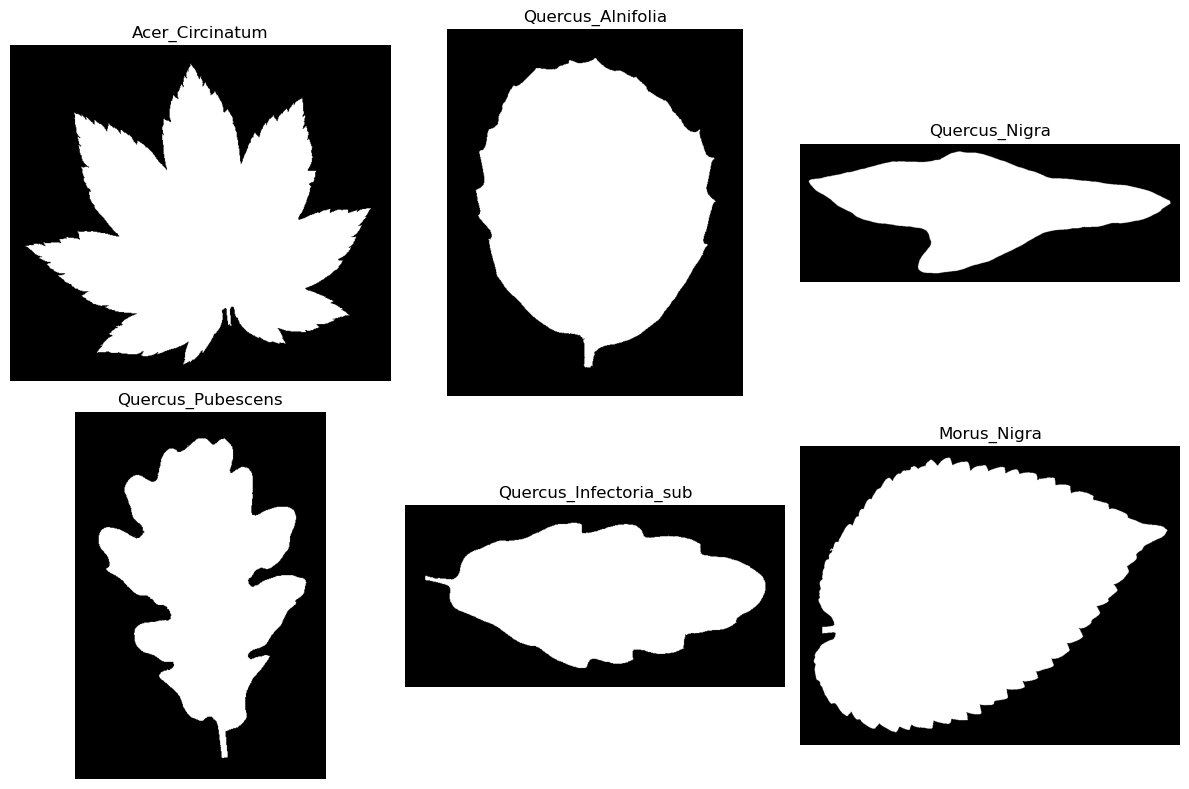

In [28]:
# Visualize examples from several species.
sample_species = train_df["species"].drop_duplicates().sample(6, random_state=42).tolist()

plt.figure(figsize=(12, 8))

for i, sp in enumerate(sample_species, 1):
    row = train_df[train_df["species"] == sp].sample(1, random_state=42).iloc[0]
    img = Image.open(row["image_path"]).convert("RGB")
    
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(sp)
    plt.axis("off")

plt.tight_layout()
plt.show()

# 3 Cross-validation

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

### transforms

In [43]:
from torchvision import transforms

IMAGE_SIZE = 128

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [15]:
class LeafDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image, row["id"]

        label = int(row["label"])
        return image, label

### StratifiedKFold

In [37]:
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5
RANDOM_STATE = 42

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

fold_indices = list(skf.split(train_df, train_df["label"]))

print("Number of folds:", len(fold_indices))
for fold, (train_idx, val_idx) in enumerate(fold_indices):
    print(f"Fold {fold+1}: train={len(train_idx)}, val={len(val_idx)}")

Number of folds: 5
Fold 1: train=792, val=198
Fold 2: train=792, val=198
Fold 3: train=792, val=198
Fold 4: train=792, val=198
Fold 5: train=792, val=198


In [38]:
for fold, (train_idx, val_idx) in enumerate(fold_indices):
    fold_train_df = train_df.iloc[train_idx]
    fold_val_df = train_df.iloc[val_idx]
    print(
        f"Fold {fold+1}: "
        f"train classes={fold_train_df['label'].nunique()}, "
        f"val classes={fold_val_df['label'].nunique()}"
    )

Fold 1: train classes=99, val classes=99
Fold 2: train classes=99, val classes=99
Fold 3: train classes=99, val classes=99
Fold 4: train classes=99, val classes=99
Fold 5: train classes=99, val classes=99


In [39]:
for fold, (train_idx, val_idx) in enumerate(fold_indices):
    fold_train_df = train_df.iloc[train_idx]
    fold_val_df = train_df.iloc[val_idx]
    
    print(f"\nFold {fold+1}")
    print("Train label distribution summary:")
    print(fold_train_df["label"].value_counts().describe())
    print("Validation label distribution summary:")
    print(fold_val_df["label"].value_counts().describe())


Fold 1
Train label distribution summary:
count    99.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: count, dtype: float64
Validation label distribution summary:
count    99.0
mean      2.0
std       0.0
min       2.0
25%       2.0
50%       2.0
75%       2.0
max       2.0
Name: count, dtype: float64

Fold 2
Train label distribution summary:
count    99.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: count, dtype: float64
Validation label distribution summary:
count    99.0
mean      2.0
std       0.0
min       2.0
25%       2.0
50%       2.0
75%       2.0
max       2.0
Name: count, dtype: float64

Fold 3
Train label distribution summary:
count    99.0
mean      8.0
std       0.0
min       8.0
25%       8.0
50%       8.0
75%       8.0
max       8.0
Name: count, dtype: float64
Validation label distribution summary:
count    99.0
mean      2.0
std       0.0
min       2.0
2

In [40]:
BATCH_SIZE = 32

def make_fold_loaders(train_df, fold_indices, fold_num, train_transform, val_transform, batch_size=32):
    train_idx, val_idx = fold_indices[fold_num]
    
    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = train_df.iloc[val_idx].reset_index(drop=True)
    
    fold_train_ds = LeafDataset(fold_train_df, transform=train_transform, is_test=False)
    fold_val_ds = LeafDataset(fold_val_df, transform=val_transform, is_test=False)
    
    fold_train_loader = DataLoader(fold_train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    fold_val_loader = DataLoader(fold_val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    
    return fold_train_df, fold_val_df, fold_train_loader, fold_val_loader

In [41]:
fold_num = 0  # first fold

fold_train_df, fold_val_df, train_loader, val_loader = make_fold_loaders(
    train_df=train_df,
    fold_indices=fold_indices,
    fold_num=fold_num,
    train_transform=train_transform,
    val_transform=val_test_transform,
    batch_size=BATCH_SIZE
)

print("Fold 1 train shape:", fold_train_df.shape)
print("Fold 1 val shape:", fold_val_df.shape)
print("Number of train batches:", len(train_loader))
print("Number of val batches:", len(val_loader))

images, labels = next(iter(train_loader))
print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("labels[:10]:", labels[:10])

Fold 1 train shape: (792, 197)
Fold 1 val shape: (198, 197)
Number of train batches: 25
Number of val batches: 7
images shape: torch.Size([32, 3, 128, 128])
labels shape: torch.Size([32])
labels[:10]: tensor([94, 27, 88, 88, 33, 41, 21, 70, 73, 94])


In [42]:
fold_summary = []

for fold, (train_idx, val_idx) in enumerate(fold_indices):
    fold_summary.append({
        "fold": fold + 1,
        "train_size": len(train_idx),
        "val_size": len(val_idx),
        "num_train_classes": train_df.iloc[train_idx]["label"].nunique(),
        "num_val_classes": train_df.iloc[val_idx]["label"].nunique()
    })

fold_summary_df = pd.DataFrame(fold_summary)
display(fold_summary_df)

,fold,train_size,val_size,num_train_classes,num_val_classes
0,1,792,198,99,99
1,2,792,198,99,99
2,3,792,198,99,99
3,4,792,198,99,99
4,5,792,198,99,99


# 4 CNN

## Model 1: Baseline CNN

In [44]:
import torch.nn as nn

class CNNModel1(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 32 -> 16
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model 2: Deeper CNN + BatchNorm + More Dropout

In [46]:
class CNNModel2(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 16 -> 8
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model 3: CNN + Global Average Pooling

In [45]:
class CNNModel3(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 -> 64

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 -> 32

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 -> 16

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.40),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Factory

In [47]:
def build_model(model_name, num_classes):
    if model_name == "cnn1":
        return CNNModel1(num_classes)
    elif model_name == "cnn2":
        return CNNModel2(num_classes)
    elif model_name == "cnn3":
        return CNNModel3(num_classes)
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

## Train/Test 

In [48]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [49]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return epoch_loss, epoch_acc, epoch_f1

In [50]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    
    return epoch_loss, epoch_acc, epoch_f1

In [51]:
# Training function for a single fold

def run_one_fold(model_name, fold_num, train_df, fold_indices, train_transform, val_transform,
                 num_classes, batch_size=32, lr=1e-3, epochs=10, weight_decay=0.0):
    
    fold_train_df, fold_val_df, train_loader, val_loader = make_fold_loaders(
        train_df=train_df,
        fold_indices=fold_indices,
        fold_num=fold_num,
        train_transform=train_transform,
        val_transform=val_transform,
        batch_size=batch_size
    )
    
    model = build_model(model_name, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    history = []
    best_val_f1 = -1
    best_state = None
    
    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
        
        history.append({
            "fold": fold_num + 1,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "train_f1": train_f1,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })
        
        print(
            f"[{model_name}] Fold {fold_num+1} | Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
        )
        
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
    
    return model, best_state, pd.DataFrame(history)

In [53]:
# cross_valitation

def run_cv_experiment(model_name, train_df, fold_indices, train_transform, val_transform,
                      num_classes, batch_size=32, lr=1e-3, epochs=10, weight_decay=0.0):
    
    all_fold_histories = []
    fold_best_results = []
    
    for fold_num in range(len(fold_indices)):
        print("=" * 80)
        print(f"Running {model_name} on Fold {fold_num+1}")
        
        _, _, history_df = run_one_fold(
            model_name=model_name,
            fold_num=fold_num,
            train_df=train_df,
            fold_indices=fold_indices,
            train_transform=train_transform,
            val_transform=val_transform,
            num_classes=num_classes,
            batch_size=batch_size,
            lr=lr,
            epochs=epochs,
            weight_decay=weight_decay
        )
        
        all_fold_histories.append(history_df)
        
        best_row = history_df.sort_values("val_f1", ascending=False).iloc[0]
        fold_best_results.append({
            "model_name": model_name,
            "fold": fold_num + 1,
            "best_epoch": int(best_row["epoch"]),
            "val_loss": best_row["val_loss"],
            "val_acc": best_row["val_acc"],
            "val_f1": best_row["val_f1"]
        })
    
    history_all_df = pd.concat(all_fold_histories, ignore_index=True)
    fold_results_df = pd.DataFrame(fold_best_results)
    
    summary_df = pd.DataFrame([{
        "model_name": model_name,
        "mean_val_acc": fold_results_df["val_acc"].mean(),
        "std_val_acc": fold_results_df["val_acc"].std(),
        "mean_val_f1": fold_results_df["val_f1"].mean(),
        "std_val_f1": fold_results_df["val_f1"].std()
    }])
    
    return history_all_df, fold_results_df, summary_df

## Run

In [54]:
experiment_configs = [
    {
        "model_name": "cnn1",
        "batch_size": 32,
        "lr": 1e-3,
        "epochs": 10,
        "weight_decay": 0.0
    },
    {
        "model_name": "cnn2",
        "batch_size": 32,
        "lr": 1e-3,
        "epochs": 10,
        "weight_decay": 1e-4
    },
    {
        "model_name": "cnn3",
        "batch_size": 32,
        "lr": 5e-4,
        "epochs": 10,
        "weight_decay": 1e-4
    }
]

In [55]:
all_summaries = []
all_fold_results = {}
all_histories = {}

for config in experiment_configs:
    print("\n" + "#" * 100)
    print("Running experiment:", config)
    
    history_df, fold_results_df, summary_df = run_cv_experiment(
        model_name=config["model_name"],
        train_df=train_df,
        fold_indices=fold_indices,
        train_transform=train_transform,
        val_transform=val_test_transform,
        num_classes=num_classes,
        batch_size=config["batch_size"],
        lr=config["lr"],
        epochs=config["epochs"],
        weight_decay=config["weight_decay"]
    )
    
    all_histories[config["model_name"]] = history_df
    all_fold_results[config["model_name"]] = fold_results_df
    all_summaries.append(summary_df)

comparison_df = pd.concat(all_summaries, ignore_index=True)
comparison_df = comparison_df.sort_values("mean_val_f1", ascending=False).reset_index(drop=True)

display(comparison_df)


####################################################################################################
Running experiment: {'model_name': 'cnn1', 'batch_size': 32, 'lr': 0.001, 'epochs': 10, 'weight_decay': 0.0}
Running cnn1 on Fold 1
[cnn1] Fold 1 | Epoch 1/10 | Train Loss: 4.6640 | Train Acc: 0.0063 | Train F1: 0.0036 | Val Loss: 4.5931 | Val Acc: 0.0152 | Val F1: 0.0025
[cnn1] Fold 1 | Epoch 2/10 | Train Loss: 4.5851 | Train Acc: 0.0076 | Train F1: 0.0029 | Val Loss: 4.5374 | Val Acc: 0.0455 | Val F1: 0.0244
[cnn1] Fold 1 | Epoch 3/10 | Train Loss: 4.3153 | Train Acc: 0.0556 | Train F1: 0.0367 | Val Loss: 3.7045 | Val Acc: 0.1818 | Val F1: 0.1239
[cnn1] Fold 1 | Epoch 4/10 | Train Loss: 3.6041 | Train Acc: 0.1566 | Train F1: 0.1371 | Val Loss: 2.8805 | Val Acc: 0.2879 | Val F1: 0.2317
[cnn1] Fold 1 | Epoch 5/10 | Train Loss: 2.8895 | Train Acc: 0.2702 | Train F1: 0.2491 | Val Loss: 2.3857 | Val Acc: 0.3939 | Val F1: 0.3447
[cnn1] Fold 1 | Epoch 6/10 | Train Loss: 2.4298 | Train Acc: 

,model_name,mean_val_acc,std_val_acc,mean_val_f1,std_val_f1
0,cnn1,0.594949,0.036490,0.555236,0.034286
1,cnn3,0.178788,0.016978,0.112881,0.012337
2,cnn2,0.131313,0.018897,0.084812,0.016992


# 5 Evaluate goodness of fit metrics.

In [56]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_with_probs(model, loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            running_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / len(loader.dataset)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)
    
    metrics = {
        "loss": epoch_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision_macro": precision_score(all_labels, all_preds, average="macro", zero_division=0),
        "recall_macro": recall_score(all_labels, all_preds, average="macro", zero_division=0),
        "f1_macro": f1_score(all_labels, all_preds, average="macro")
    }
    
    return metrics, all_labels, all_preds, all_probs

In [57]:
def run_best_model_cv(model_name, train_df, fold_indices, train_transform, val_transform,
                      num_classes, batch_size=32, lr=1e-3, epochs=10, weight_decay=0.0):
    
    all_fold_metrics = []
    all_fold_predictions = []
    all_histories = []
    
    for fold_num in range(len(fold_indices)):
        print("=" * 80)
        print(f"Running {model_name} on Fold {fold_num+1}")
        
        fold_train_df, fold_val_df, train_loader, val_loader = make_fold_loaders(
            train_df=train_df,
            fold_indices=fold_indices,
            fold_num=fold_num,
            train_transform=train_transform,
            val_transform=val_transform,
            batch_size=batch_size
        )
        
        model = build_model(model_name, num_classes).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        
        history = []
        best_val_f1 = -1
        best_state = None
        
        for epoch in range(epochs):
            train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
            
            history.append({
                "fold": fold_num + 1,
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "train_f1": train_f1,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_f1": val_f1
            })
            
            print(
                f"Fold {fold_num+1} | Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}"
            )
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                best_state = model.state_dict()
        
        model.load_state_dict(best_state)
        
        metrics, y_true, y_pred, y_prob = evaluate_with_probs(model, val_loader, criterion, device)
        
        fold_metric_row = {
            "fold": fold_num + 1,
            **metrics
        }
        all_fold_metrics.append(fold_metric_row)
        
        pred_df = pd.DataFrame({
            "fold": fold_num + 1,
            "true_label": y_true,
            "pred_label": y_pred
        })
        all_fold_predictions.append((pred_df, y_prob))
        all_histories.append(pd.DataFrame(history))
    
    metrics_df = pd.DataFrame(all_fold_metrics)
    history_df = pd.concat(all_histories, ignore_index=True)
    
    return metrics_df, history_df, all_fold_predictions

In [58]:
best_metrics_df, best_history_df, best_fold_predictions = run_best_model_cv(
    model_name="cnn1",
    train_df=train_df,
    fold_indices=fold_indices,
    train_transform=train_transform,
    val_transform=val_test_transform,
    num_classes=num_classes,
    batch_size=32,
    lr=1e-3,
    epochs=10,
    weight_decay=0.0
)

Running cnn1 on Fold 1
Fold 1 | Epoch 1/10 | Train Loss: 4.6484 | Train Acc: 0.0088 | Val Loss: 4.5954 | Val Acc: 0.0101 | Val F1: 0.0005
Fold 1 | Epoch 2/10 | Train Loss: 4.5888 | Train Acc: 0.0290 | Val Loss: 4.5454 | Val Acc: 0.0707 | Val F1: 0.0352
Fold 1 | Epoch 3/10 | Train Loss: 4.3345 | Train Acc: 0.0745 | Val Loss: 3.6038 | Val Acc: 0.1818 | Val F1: 0.1205
Fold 1 | Epoch 4/10 | Train Loss: 3.3975 | Train Acc: 0.1856 | Val Loss: 2.7924 | Val Acc: 0.3535 | Val F1: 0.2819
Fold 1 | Epoch 5/10 | Train Loss: 2.7334 | Train Acc: 0.2980 | Val Loss: 2.2438 | Val Acc: 0.3939 | Val F1: 0.3372
Fold 1 | Epoch 6/10 | Train Loss: 2.4000 | Train Acc: 0.3586 | Val Loss: 1.9718 | Val Acc: 0.4848 | Val F1: 0.4253
Fold 1 | Epoch 7/10 | Train Loss: 2.0404 | Train Acc: 0.4116 | Val Loss: 1.8502 | Val Acc: 0.4747 | Val F1: 0.4452
Fold 1 | Epoch 8/10 | Train Loss: 1.9029 | Train Acc: 0.4735 | Val Loss: 1.7238 | Val Acc: 0.5202 | Val F1: 0.4737
Fold 1 | Epoch 9/10 | Train Loss: 1.7398 | Train Acc: 0.4

In [61]:
best_metrics_df


,fold,loss,accuracy,precision_macro,recall_macro,f1_macro
0,1,1.556352,0.525253,0.490741,0.525253,0.482227
1,2,1.557614,0.570707,0.514141,0.570707,0.515873
2,3,1.519324,0.555556,0.548513,0.555556,0.523602
3,4,1.652962,0.535354,0.518519,0.535354,0.497763
4,5,1.346467,0.585859,0.559620,0.585859,0.551603


In [62]:
best_metrics_df.mean(numeric_only=True)

fold               3.000000
loss               1.526544
accuracy           0.554545
precision_macro    0.526307
recall_macro       0.554545
f1_macro           0.514214
dtype: float64

# 6 Build multi-class ROC and Precision / Recall graphs

In [63]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

In [64]:
all_true = []
all_pred = []
all_prob = []

for pred_df, y_prob in best_fold_predictions:
    all_true.extend(pred_df["true_label"].values)
    all_pred.extend(pred_df["pred_label"].values)
    all_prob.append(y_prob)

all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_prob = np.vstack(all_prob)

print("all_true shape:", all_true.shape)
print("all_prob shape:", all_prob.shape)

all_true shape: (990,)
all_prob shape: (990, 99)


In [65]:
y_true_bin = label_binarize(all_true, classes=np.arange(num_classes))

print("y_true_bin shape:", y_true_bin.shape)

y_true_bin shape: (990, 99)


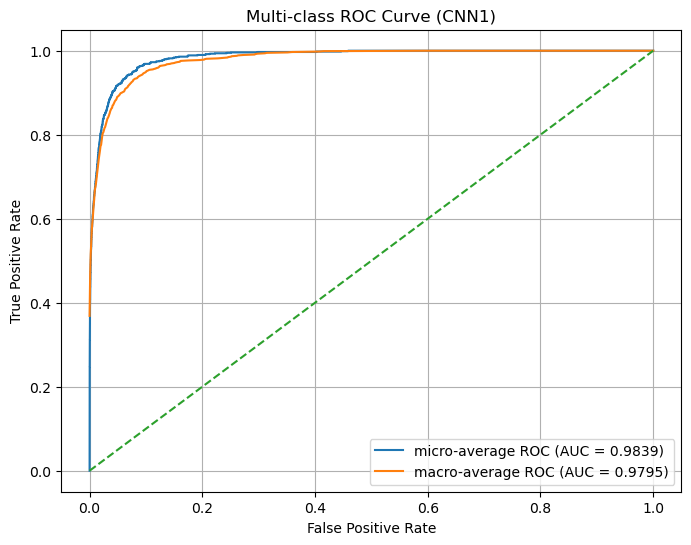

In [67]:
# Multi-class ROC curve

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# micro-average ROC
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), all_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

plt.figure(figsize=(8, 6))
plt.plot(fpr["micro"], tpr["micro"],
         label=f"micro-average ROC (AUC = {roc_auc['micro']:.4f})")
plt.plot(fpr["macro"], tpr["macro"],
         label=f"macro-average ROC (AUC = {roc_auc['macro']:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve (CNN1)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

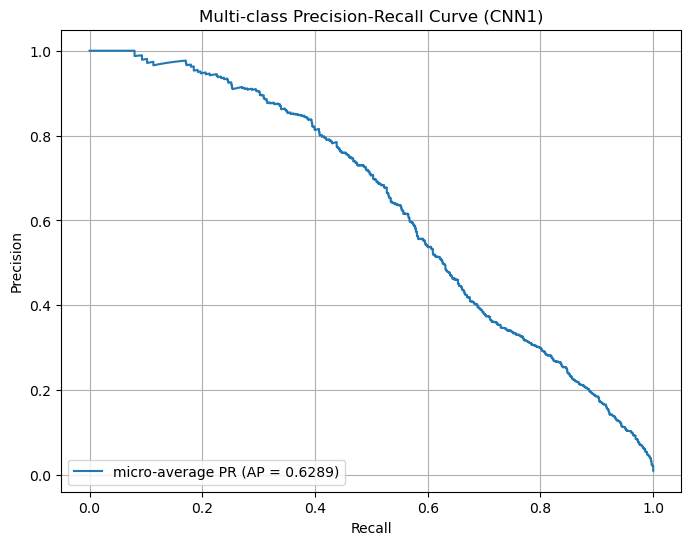

Macro-average AP: 0.6101624995163498
Micro-average AP: 0.6289298435562398


In [69]:
# Multi-class Precision-Recall curve

precision = dict()
recall = dict()
avg_precision = dict()

for i in range(num_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], all_prob[:, i])
    avg_precision[i] = average_precision_score(y_true_bin[:, i], all_prob[:, i])

# micro-average PR
precision["micro"], recall["micro"], _ = precision_recall_curve(
    y_true_bin.ravel(), all_prob.ravel()
)
avg_precision["micro"] = average_precision_score(y_true_bin, all_prob, average="micro")

# macro-average AP
avg_precision["macro"] = average_precision_score(y_true_bin, all_prob, average="macro")

plt.figure(figsize=(8, 6))
plt.plot(recall["micro"], precision["micro"],
         label=f"micro-average PR (AP = {avg_precision['micro']:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multi-class Precision-Recall Curve (CNN1)")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

print("Macro-average AP:", avg_precision["macro"])
print("Micro-average AP:", avg_precision["micro"])

In [74]:
# classification report

report = classification_report(
    all_true,
    all_pred,
    target_names=sorted(train_df["species"].unique()),  
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.head()

,precision,recall,f1-score,support
Acer_Capillipes,0.583333,0.7,0.636364,10.0
Acer_Circinatum,1.000000,1.0,1.000000,10.0
Acer_Mono,0.900000,0.9,0.900000,10.0
Acer_Opalus,1.000000,0.9,0.947368,10.0
Acer_Palmatum,0.769231,1.0,0.869565,10.0


# 7 classify the test data

In [77]:
import os

DATA_DIR = "leaf-classification"
print(os.listdir(DATA_DIR)[:10])


['images', 'sample_submission.csv', 'test.csv', 'train.csv']


In [79]:
test_images_dir = os.path.join(DATA_DIR, "images")

test_df["image_path"] = test_df["id"].apply(lambda x: os.path.join(test_images_dir, f"{x}.jpg"))
test_df.head()

C:\Users\zdxzh\AppData\Local\Temp\ipykernel_37608\2882008786.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_df["image_path"] = test_df["id"].apply(lambda x: os.path.join(test_images_dir, f"{x}.jpg"))


,id,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,margin9,...,texture56,texture57,texture58,texture59,texture60,texture61,texture62,texture63,texture64,image_path
0,4,0.019531,0.009766,0.078125,0.011719,0.003906,0.015625,0.005859,0.0,0.005859,...,0.000000,0.015625,0.000977,0.015625,0.0,0.0,0.000000,0.003906,0.053711,leaf-classification\images\4.jpg
1,7,0.007812,0.005859,0.064453,0.009766,0.003906,0.013672,0.007812,0.0,0.033203,...,0.000000,0.006836,0.001953,0.013672,0.0,0.0,0.000977,0.037109,0.044922,leaf-classification\images\7.jpg
2,9,0.000000,0.000000,0.001953,0.021484,0.041016,0.000000,0.023438,0.0,0.011719,...,0.000000,0.000977,0.000000,0.000000,0.0,0.0,0.015625,0.000000,0.000000,leaf-classification\images\9.jpg
3,12,0.000000,0.000000,0.009766,0.011719,0.017578,0.000000,0.003906,0.0,0.003906,...,0.015625,0.002930,0.036133,0.013672,0.0,0.0,0.089844,0.000000,0.008789,leaf-classification\images\12.jpg
4,13,0.001953,0.000000,0.015625,0.009766,0.039062,0.000000,0.009766,0.0,0.005859,...,0.042969,0.016602,0.010742,0.041016,0.0,0.0,0.007812,0.009766,0.007812,leaf-classification\images\13.jpg


In [84]:
print(train_df.columns.tolist())
train_df.head()

['id', 'species', 'margin1', 'margin2', 'margin3', 'margin4', 'margin5', 'margin6', 'margin7', 'margin8', 'margin9', 'margin10', 'margin11', 'margin12', 'margin13', 'margin14', 'margin15', 'margin16', 'margin17', 'margin18', 'margin19', 'margin20', 'margin21', 'margin22', 'margin23', 'margin24', 'margin25', 'margin26', 'margin27', 'margin28', 'margin29', 'margin30', 'margin31', 'margin32', 'margin33', 'margin34', 'margin35', 'margin36', 'margin37', 'margin38', 'margin39', 'margin40', 'margin41', 'margin42', 'margin43', 'margin44', 'margin45', 'margin46', 'margin47', 'margin48', 'margin49', 'margin50', 'margin51', 'margin52', 'margin53', 'margin54', 'margin55', 'margin56', 'margin57', 'margin58', 'margin59', 'margin60', 'margin61', 'margin62', 'margin63', 'margin64', 'shape1', 'shape2', 'shape3', 'shape4', 'shape5', 'shape6', 'shape7', 'shape8', 'shape9', 'shape10', 'shape11', 'shape12', 'shape13', 'shape14', 'shape15', 'shape16', 'shape17', 'shape18', 'shape19', 'shape20', 'shape21', '

,id,species,margin1,margin2,margin3,margin4,margin5,margin6,margin7,margin8,...,texture58,texture59,texture60,texture61,texture62,texture63,texture64,image_path,label,file_exists
0,1,Acer_Opalus,0.007812,0.023438,0.023438,0.003906,0.011719,0.009766,0.027344,0.0,...,0.002930,0.035156,0.0,0.0,0.004883,0.000000,0.025391,leaf-classification\images\1.jpg,3,True
1,2,Pterocarya_Stenoptera,0.005859,0.000000,0.031250,0.015625,0.025391,0.001953,0.019531,0.0,...,0.000977,0.023438,0.0,0.0,0.000977,0.039062,0.022461,leaf-classification\images\2.jpg,49,True
2,3,Quercus_Hartwissiana,0.005859,0.009766,0.019531,0.007812,0.003906,0.005859,0.068359,0.0,...,0.000977,0.007812,0.0,0.0,0.000000,0.020508,0.002930,leaf-classification\images\3.jpg,65,True
3,5,Tilia_Tomentosa,0.000000,0.003906,0.023438,0.005859,0.021484,0.019531,0.023438,0.0,...,0.000000,0.020508,0.0,0.0,0.017578,0.000000,0.047852,leaf-classification\images\5.jpg,94,True
4,6,Quercus_Variabilis,0.005859,0.003906,0.048828,0.009766,0.013672,0.015625,0.005859,0.0,...,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.031250,leaf-classification\images\6.jpg,84,True


In [80]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class LeafTestDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        image_id = self.df.loc[idx, "id"]
        return image, image_id

## full train

In [85]:
class LeafTrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image_path"]
        label = self.df.loc[idx, "label"]
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [86]:
BATCH_SIZE = 32

full_train_dataset = LeafTrainDataset(train_df, transform=train_transform)
test_dataset = LeafTestDataset(test_df, transform=val_test_transform)

full_train_loader = DataLoader(full_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Full train size:", len(full_train_dataset))
print("Test size:", len(test_dataset))

Full train size: 990
Test size: 594


In [88]:
final_model = build_model("cnn1", num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-3, weight_decay=0.0)

FINAL_EPOCHS = 12

final_history = []

for epoch in range(FINAL_EPOCHS):
    train_loss, train_acc, train_f1 = train_one_epoch(
        final_model, full_train_loader, criterion, optimizer, device
    )
    
    final_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1
    })
    
    print(
        f"Epoch {epoch+1}/{FINAL_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f}"
    )

Epoch 1/12 | Train Loss: 4.6824 | Train Acc: 0.0071 | Train F1: 0.0043
Epoch 2/12 | Train Loss: 4.4145 | Train Acc: 0.0354 | Train F1: 0.0327
Epoch 3/12 | Train Loss: 3.3960 | Train Acc: 0.1838 | Train F1: 0.1667
Epoch 4/12 | Train Loss: 2.5731 | Train Acc: 0.3394 | Train F1: 0.3142
Epoch 5/12 | Train Loss: 2.2100 | Train Acc: 0.3929 | Train F1: 0.3757
Epoch 6/12 | Train Loss: 1.9952 | Train Acc: 0.4475 | Train F1: 0.4352
Epoch 7/12 | Train Loss: 1.7551 | Train Acc: 0.4980 | Train F1: 0.4855
Epoch 8/12 | Train Loss: 1.5864 | Train Acc: 0.5273 | Train F1: 0.5197
Epoch 9/12 | Train Loss: 1.4871 | Train Acc: 0.5636 | Train F1: 0.5536
Epoch 10/12 | Train Loss: 1.3270 | Train Acc: 0.6071 | Train F1: 0.5977
Epoch 11/12 | Train Loss: 1.3254 | Train Acc: 0.6010 | Train F1: 0.5942
Epoch 12/12 | Train Loss: 1.1671 | Train Acc: 0.6424 | Train F1: 0.6370


In [89]:
final_history_df = pd.DataFrame(final_history)
final_history_df

,epoch,train_loss,train_acc,train_f1
0,1,4.682376,0.007071,0.004304
1,2,4.414542,0.035354,0.032665
2,3,3.395987,0.183838,0.166720
3,4,2.573088,0.339394,0.314152
4,5,2.209998,0.392929,0.375675
5,6,1.995236,0.447475,0.435223
6,7,1.755138,0.497980,0.485540
7,8,1.586431,0.527273,0.519695
8,9,1.487056,0.563636,0.553614
9,10,1.326957,0.607071,0.597677


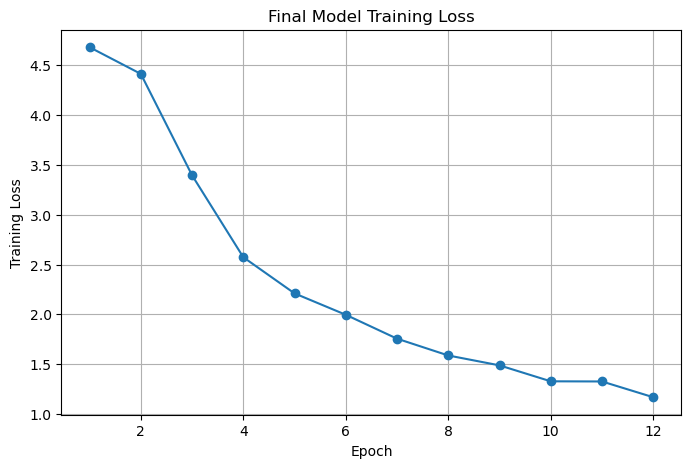

In [92]:
plt.figure(figsize=(8, 5))
plt.plot(final_history_df["epoch"], final_history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Final Model Training Loss")
plt.grid(True)
plt.show()

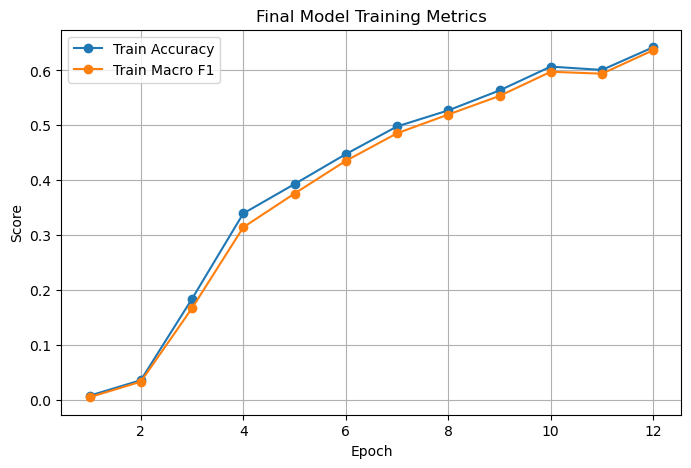

In [91]:
plt.figure(figsize=(8, 5))
plt.plot(final_history_df["epoch"], final_history_df["train_acc"], marker="o", label="Train Accuracy")
plt.plot(final_history_df["epoch"], final_history_df["train_f1"], marker="o", label="Train Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Final Model Training Metrics")
plt.legend()
plt.grid(True)
plt.show()

## test set


In [98]:
def predict_test(model, loader, device):
    model.eval()
    
    all_ids = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, image_ids in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_ids.extend(image_ids)
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return all_ids, np.array(all_preds), np.array(all_probs)

In [99]:
test_ids, test_pred_encoded, test_pred_probs = predict_test(final_model, test_loader, device)

print(len(test_ids), test_pred_encoded.shape, test_pred_probs.shape)

594 (594,) (594, 99)


In [104]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(train_df["species"])

LabelEncoder()

In [105]:
test_pred_labels = label_encoder.inverse_transform(test_pred_encoded)
test_pred_labels[:10]

array(['Viburnum_Tinus', 'Quercus_Brantii', 'Acer_Circinatum',
       'Castanea_Sativa', 'Ilex_Cornuta', 'Acer_Opalus', 'Acer_Opalus',
       'Eucalyptus_Glaucescens', 'Quercus_Variabilis', 'Acer_Rufinerve'],
      dtype=object)

In [109]:
submission_df = pd.DataFrame({
    "id": test_ids,
    "species": test_pred_labels
})

submission_df.head()

,id,species
0,tensor(4),Viburnum_Tinus
1,tensor(7),Quercus_Brantii
2,tensor(9),Acer_Circinatum
3,tensor(12),Castanea_Sativa
4,tensor(13),Ilex_Cornuta


# Discussion

Among the three CNN architectures, CNN1 achieved the best overall performance. It obtained the highest mean validation accuracy and macro F1-score across the 5-fold cross-validation process, indicating that a relatively simple architecture generalized better on this dataset than deeper alternatives.

CNN2 and CNN3 performed substantially worse, suggesting that increasing model complexity did not improve performance for this task. This is likely due to the relatively small number of training samples per class and the fine-grained nature of the 99-class leaf classification problem. In such settings, deeper models can be harder to optimize and more prone to overfitting or unstable learning.

For the best model (CNN1), the average validation accuracy was approximately 0.55 and the macro F1-score was approximately 0.51. These results indicate that the model learned meaningful class-discriminative patterns, although the classification task remained challenging. The multi-class ROC and Precision-Recall analysis further showed that the model produced useful probability estimates across classes.

Overall, the experiments demonstrate that model selection and hyperparameter tuning are important in small, multi-class image classification tasks. A simpler CNN with appropriate regularization was more effective than deeper architectures for this assignment.